<a href="https://colab.research.google.com/github/sarodeshital/Global-E-Commerce-Project/blob/main/E_Commerce_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **GLOBAL E-COMMERCE PROJECT**

**CELL 1 - LIBRARY IMPORTS**

In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

In [164]:
# Global style setting - applied once, they cascade across all charts


In [165]:
warnings.filterwarnings("ignore")
sns.set_theme (style="darkgrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

print("All liabraries imorted successfully!")


All liabraries imorted successfully!


**CELL 2 - LOAD THE DATASET**

In [166]:
file_path = "/ecommerce_dataset_+1m.csv"

In [167]:
file_path = "/content/ecommerce_dataset_+1m.csv"
df = pd.read_csv(file_path, low_memory=False)

print(f"Dataset loaded successfully!")
print(f"Shape : {df.shape[0]:,} rows * {df.shape[1]} columns")
print(f"Memory:{df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Dataset loaded successfully!
Shape : 1,000,123 rows * 62 columns
Memory:2166.8 MB


**CELL 3 - BASIC INSPECTION**

In [168]:
print("=" * 60)
print("FIRST 3 ROWS")
print("=" * 60)
print (df.head(3).to_string())

FIRST 3 ROWS
    order_id                  order_date  order_year  order_month  order_day  order_hour  order_minute  order_second is_weekend order_status return_reason customer_id    customer_name gender  age customer_segment        country         city  customer_loyalty_score  total_orders_by_customer account_creation_date product_id            product_name category sub_category brand  product_rating_avg  product_reviews_count  stock_quantity  unit_price_usd  quantity  discount_percent  discount_amount_usd  total_price_usd  cost_usd  profit_usd  tax_usd currency payment_method payment_status installment_plan shipping_method  shipping_cost_usd  delivery_days shipping_country warehouse_location delivery_status  rating review_sentiment     customer_feedback coupon_used coupon_code campaign_source device_type traffic_source  session_duration_minutes  pages_visited abandoned_cart_before  fraud_risk_score  profit_margin_percent order_priority support_ticket_created
0  ORD-XAJI0  2024-10-14 

In [169]:
print("=" * 60)
print("DATASET INFO")
print("=" * 60)
df.info(verbose=True, show_counts=True)

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000123 entries, 0 to 1000122
Data columns (total 62 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   order_id                  1000123 non-null  object 
 1   order_date                1000123 non-null  object 
 2   order_year                1000123 non-null  int64  
 3   order_month               1000123 non-null  int64  
 4   order_day                 1000123 non-null  int64  
 5   order_hour                1000123 non-null  int64  
 6   order_minute              1000123 non-null  int64  
 7   order_second              1000123 non-null  int64  
 8   is_weekend                1000123 non-null  object 
 9   order_status              1000123 non-null  object 
 10  return_reason             99879 non-null    object 
 11  customer_id               1000123 non-null  object 
 12  customer_name             1000123 non-null  object 
 13  gender        

In [170]:
print("\n" + "=" * 60)
print("STASTICAL SUMMARY (Numerical Columns)")
print("=" * 60)
print(df.describe().round(2).to_string())


STASTICAL SUMMARY (Numerical Columns)
       order_year  order_month   order_day  order_hour  order_minute  order_second         age  customer_loyalty_score  total_orders_by_customer  product_rating_avg  product_reviews_count  stock_quantity  unit_price_usd    quantity  discount_percent  discount_amount_usd  total_price_usd    cost_usd  profit_usd     tax_usd  shipping_cost_usd  delivery_days      rating  session_duration_minutes  pages_visited  fraud_risk_score  profit_margin_percent
count  1000123.00   1000123.00  1000123.00  1000123.00    1000123.00    1000123.00  1000123.00              1000123.00                1000123.00          1000123.00             1000123.00      1000123.00      1000123.00  1000123.00         1000123.0           1000123.00       1000123.00  1000123.00  1000123.00  1000123.00         1000123.00     1000123.00  1000123.00                1000123.00     1000123.00        1000123.00             1000123.00
mean      2024.59         6.51       15.75       11.49   

In [171]:
print("\n" + "=" * 60)
print("STASTICAL SUMMARY (Categorical Columns)")
print("=" * 60)
print(df.describe(include="object").to_string())


STASTICAL SUMMARY (Categorical Columns)
         order_id                  order_date is_weekend order_status return_reason customer_id  customer_name   gender customer_segment      country     city account_creation_date product_id            product_name category sub_category    brand currency payment_method payment_status installment_plan shipping_method shipping_country warehouse_location delivery_status review_sentiment customer_feedback coupon_used coupon_code campaign_source device_type traffic_source abandoned_cart_before order_priority support_ticket_created
count     1000123                     1000123    1000123      1000123         99879     1000123        1000123  1000123          1000123      1000123  1000123               1000123    1000123                 1000123  1000123      1000123  1000123  1000123        1000123        1000123          1000123         1000123          1000123            1000123         1000123          1000123            800506     1000123      500

**CELL 4 - MISSING VALUES**

In [172]:
#  Step 4a Measure Missing Value

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
}).query("`Missing Count` > 0").sort_values("Missing %", ascending=False)

print("Missing Value Report:")
print(missing_report.to_string())
print(f"\nTotal columns with missing data: {len(missing_report)}")

Missing Value Report:
                   Missing Count  Missing %
return_reason             900244      90.01
coupon_code               500083      50.00
customer_feedback         199617      19.96

Total columns with missing data: 3


In [173]:
# Step 4 Apply the filling strategy

In [174]:
for col in df.columns:
    pct = df[col].isnull().mean() * 100
    if pct == 0:
        continue
    if pct > 30:
        df.drop(columns=[col], inplace=True)
        print(f"Dropped '{col}' ({pct:.1f}% missing)")
    elif df[col].dtype in ["float64", "int64"]:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"Filled '{col}' with median ({pct:.1f}% missing)")
    else:
        if col == "return_reason":
            df[col].fillna("No Return", inplace=True)
        elif col == "customer_feedback":
            df[col].fillna("No Feedback", inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f"Filled '{col}' with mode/label ({pct:.1f}% missing)")
print(f"\nMissing values handled. Remaining nulls: {df.isnull().sum().sum()}")

Dropped 'return_reason' (90.0% missing)
Dropped 'coupon_code' (50.0% missing)

Missing values handled. Remaining nulls: 0


**CELL 5 - REMOVE DUPLICATE**

In [175]:
# --- Step 5: Remove Duplicate Records ---

In [176]:
before = len(df)
df.drop_duplicates(inplace=True)
df.drop_duplicates(subset=["order_id"], keep="first", inplace=True)
after = len(df)

print(f"Duplicates removed.")
print(f"Before: {before:,} rows")
print(f"After: {after:,} rows")
print(f"Removed: {before - after:,} duplicate rows")

Duplicates removed.
Before: 1,000,123 rows
After: 991,930 rows
Removed: 8,193 duplicate rows


**CELL 6 - OUTLIER HANDLING (IQR)**

In [177]:
# A Step 6: Handle Outliers Using the IQR Method

In [178]:
# Column where outliers are financially meaningful

outlier_cols = [
    "unit_price_usd",
    "total_price_usd",
    "profit_usd",
    "shipping_cost_usd",
    "discount_amount_usd",
    "quantity"]

outlier_summary = []

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    # Cap the values

    df[col] = df[col].clip(lower=lower, upper=upper)
    outlier_summary.append({
        "Column": col,
        "Lower Fence": round(lower, 2),
        "Upper Fence": round(upper, 2),
        "Outliers Capped": n_outliers
    })

**CELL 7 - DATA TYPE CONVERSION**

In [179]:
#Step 7: Data Type Conversion

In [180]:
# Convert date columns to datetime

date_cols = ['order_date',
             'account_creation_date']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")
        print(f"'{col}' → datetime64 | nulls after convert: {df[col].isnull().sum()}")

# Ensure numeric columns are numeric (defensive step)

num_cols = ["unit_price_usd", "total_price_usd", "profit_usd",
            "cost_usd", "tax_usd", "shipping_cost_usd",
            "quantity", "discount_percent", "customer_loyalty_score"]
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Confirm the key dtypes

print("\nKey Column Data Types After Conversion: ")
for col in date_cols + num_cols[:4]:
    if col in df.columns:
        print(f" {col} → {df[col].dtype}")

'order_date' → datetime64 | nulls after convert: 0
'account_creation_date' → datetime64 | nulls after convert: 0

Key Column Data Types After Conversion: 
 order_date → datetime64[ns]
 account_creation_date → datetime64[ns]
 unit_price_usd → float64
 total_price_usd → float64
 profit_usd → float64
 cost_usd → float64


**CELL 8 - FEATURE ENGINEERING**

In [181]:
# * Step 8: Feature Engineering - Creating New, Smarter Columns

In [182]:
# 1. Revenue after discount
df["revenue_after_discount"] = df["total_price_usd"] - df["discount_amount_usd"]

# 2. Profit margin percentage (protect against divide-by-zero)
df["profit_margin_pct"] = np.where(
    df["total_price_usd"] > 0,
    ((df["profit_usd"] / df["total_price_usd"]) * 100).round(2),
    0
)

# 3. Order Year-Month (for time series grouping)
df["order_year_month"] = df["order_date"].dt.to_period("M").astype(str)

# 4. Day of week name
df["order_day_of_week"] = df["order_date"].dt.day_name()

# 5. Time-of-day buckets
def hour_to_bin(h):
    if 5 <= h < 12:
        return "Morning (5-12)"
    elif 12 <= h < 17:
        return "Afternoon (12-17)"
    elif 17 <= h < 21:
        return "Evening (17-21)"
    return "Night (21-5)"
df["order_hour_bin"] = df["order_hour"].apply(hour_to_bin)

# 6. Customer Lifetime Value proxy
clv_map = df.groupby("customer_id")["total_price_usd"].sum()
df["customer_lifetime_value"] = df["customer_id"].map(clv_map).round(2)

# 7. Shipping efficiency (cost per delivery day, lower = better)
df["shipping_efficiency"] = np.where(
    df["delivery_days"] > 0,
    (df["shipping_cost_usd"] / df["delivery_days"]).round(3),
    np.nan
)

# 8. High-value order flag
high_val_threshold = df["total_price_usd"].quantile(0.75)
df["is_high_value_order"] = (df["total_price_usd"] >= high_val_threshold).astype(int)

print("Feature Engineering Complete! New Columns Created:")
new_cols = ["revenue_after_discount", "profit_margin_pct",
            "order_day_of_week",
            "order_hour_bin",
            "order_year_month",
            "customer_lifetime_value",
            "shipping_efficiency", "is_high_value_order"]
for c in new_cols:
    print(f"{c: <35} | dtype: {df[c].dtype} | sample: {df[c].iloc[1]}")

print(f"\nDataset now has {df.shape[1]} columns.")

Feature Engineering Complete! New Columns Created:
revenue_after_discount              | dtype: float64 | sample: 84.46000000000001
profit_margin_pct                   | dtype: float64 | sample: 33.91
order_day_of_week                   | dtype: object | sample: Monday
order_hour_bin                      | dtype: object | sample: Night (21-5)
order_year_month                    | dtype: object | sample: 2024-10
customer_lifetime_value             | dtype: float64 | sample: 102.56
shipping_efficiency                 | dtype: float64 | sample: 1.827
is_high_value_order                 | dtype: int64 | sample: 0

Dataset now has 68 columns.


**CELL 9 - KEY PERFORMANCE INDICATORS**

In [183]:
#Step 9: Calculate 6 Key Business KPIs

In [184]:
# KPI 1: Total Revenue (after discounts)
kpi_total_revenue = df["revenue_after_discount"].sum()

# KPI 2: Total Orders
kpi_total_orders = df["order_id"].nunique()

# KPI 3: Average Order Value
kpi_avg_order_value = df["revenue_after_discount"].mean()

# KPI 4: Overall Profit Margin %
kpi_profit_margin = (df["profit_usd"].sum() / df["total_price_usd"].sum()) * 100

# KPI 5: Top Category by Revenue
top_category_revenue_df = df.groupby("category")["revenue_after_discount"].sum()
top_category = top_category_revenue_df.idxmax()
top_category_revenue = top_category_revenue_df.max()

# KPI 6: Top Customer Segment by Revenue
top_segment = (
    df.groupby("customer_segment")["revenue_after_discount"]
    .sum()
    .idxmax()
)
print("=" * 55)
print("EXECUTIVE KPI DASHBOARD")
print("=" * 55)
print(f"Total Revenue (Post-Discount      : ${kpi_total_revenue:>15,.0f}")
print(f"Total Orders                      : {kpi_total_orders: >15,}")
print(f"Avg Order Value                   : ${kpi_avg_order_value:>15.2f}")
print(f"Overall Profit Margin             : {kpi_profit_margin:>14.2f}%")
print(f"Top Category by Revenue           : {top_category: >15}")
print(f"Revenue                           : ${top_category_revenue:>15,.0f}")
print(f"Top Customer Segmen               : {top_segment: >15}")
print("=" * 55)

EXECUTIVE KPI DASHBOARD
Total Revenue (Post-Discount      : $    349,725,231
Total Orders                      :         991,930
Avg Order Value                   : $         352.57
Overall Profit Margin             :          39.15%
Top Category by Revenue           :     Electronics
Revenue                           : $    111,928,195
Top Customer Segmen               :         Regular


**CELL 10 - VISUAL 1: Monthly Sales Trend**

In [185]:
monthly = (
df.groupby("order_year_month")["revenue_after_discount" ]
.sum()
.reset_index ()
.rename(columns={"revenue_after_discount": "Revenue"})
.sort_values ("order_year_month")
)

fig1 = px.line(
monthly,
x= "order_year_month", y= "Revenue",
title="Monthly Revenue Trend (2024-2026)",
labels= {"order_year_month": "Month", "Revenue": "Revenue (USD)"},
markers=True, color_discrete_sequence=["#00B4D8"]
)
fig1.update_layout(
plot_bgcolor="#0d1117",
paper_bgcolor="#0d1117", font_color="#e6edf3",
title_font_size=18, xaxis_tickangle=-45,
hovermode="x unified"
)
fig1.update_traces(line_width=2.5, marker_size=6)
fig1.show()

**CELL 11 - VISUAL 2: Revenue by Category**

In [186]:
cat_rev = (
df.groupby("category")["revenue_after_discount" ]
.sum()
.sort_values(ascending=True)
.reset_index ()
)

fig2 = px.bar(
cat_rev,
x="revenue_after_discount", y= "category",orientation="h",
title="Total Revenue by Product Category",
labels={"revenue_after_discount": "Revenue (USD)", "category": "Category"},
color="revenue_after_discount", color_continuous_scale="Blues", text_auto=".3s"
)
fig2.update_layout(
plot_bgcolor="#0d1117", paper_bgcolor="#0d1117", font_color="#e6edf3",
title_font_size=18, coloraxis_showscale=False, showlegend=False
)
fig2.update_traces (textfont_color="#e6edf3")
fig2.show()

**CELL 12 - VISUAL 3: Top 10 Countries by Revenue**

In [187]:
country_rev = (
df.groupby("country")["revenue_after_discount"]
.sum()
.sort_values(ascending=False)
.head(10)
.reset_index()
)

fig3 = px.bar(
country_rev, x="country",
y="revenue_after_discount",title="Top 10 Countries by Revenue",
labels={
"revenue_after_discount": "Revenue (USD)",
"country": "Country"
},
color="revenue_after_discount", color_continuous_scale="Teal", text_auto=".3s"
)
fig3.update_layout(
plot_bgcolor="#0d1117", paper_bgcolor="#0d1117", font_color="#e6edf3", title_font_size=18, coloraxis_showscale=False, xaxis_tickangle=-30
)
fig3.show()

**CELL 13 - VISUAL 4: Customer Segment Analysis**

In [188]:

# Visual 4: Revenue & Profit by Customer Segment
# Why this matters:
# A grouped bar chart comparing revenue vs. profit per customer segment exposes which segment is truly profitable vs. which just drives volume.
# VIP customers may generate high revenue but also trigger high discounts.

# Group by customer_segment to get Revenue, Profit, and Order Count
seg = df.groupby("customer_segment").agg(
    Revenue=("revenue_after_discount", "sum"),
    Profit=("profit_usd", "sum"),
    Orders=("order_id", "count")
).reset_index()

# Variables for plotly
fig4 = go.Figure()
fig4.add_trace(go.Bar(name="Revenue", x=seg["customer_segment"],
                       y=seg["Revenue"], marker_color="#00B4D8"))
fig4.add_trace(go.Bar(name="Profit", x=seg["customer_segment"],
                       y=seg["Profit"], marker_color="#90E0EF"))

fig4.update_layout(
    barmode="group",
    title="Revenue vs Profit by Customer Segment",
    plot_bgcolor="#0d1117",
    paper_bgcolor="#0d1117",
    font_color="#e6edf3",
    title_font_size=18,
    legend=dict(bgcolor="#161b22"),
    xaxis_title="Customer Segment",
    yaxis_title="Amount (USD)"
)
fig4.show()

**CELL 14 - VISUAL 5: Payment Method Distribution**

In [189]:
# Visual 5: Payment Method Share (Donut Chart)
# **Why this matters:**
# Payment method distribution helps the finance and checkout teams know which gateways to prioritize,
# optimize for,
# and negotiate better fees with.
# A donut chart is perfect for "part of a whole" stories

# Variables
pay = df["payment_method"].value_counts().reset_index()
pay.columns = ["Payment Method", "Count"]

fig5 = px.pie(
    pay,
    names="Payment Method",
    values="Count",
    title="Payment Method Distribution",
    hole=0.45,
    color_discrete_sequence=px.colors.sequential.Blues_r
)

fig5.update_layout(
    plot_bgcolor="#0d1117",
    paper_bgcolor="#0d1117",
    font_color="#e6edf3",
    title_font_size=18,
    legend=dict(bgcolor="#161b22")
)

fig5.update_traces(textposition="outside", textinfo="percent+label")
fig5.show()

**CELL 15 - VISUAL 6: Order Status Breakdown**

In [190]:

# • Visual 6: Order Status Breakdown
# **Why this matters:**
# A high proportion of "Cancelled" or "Returned" orders signals customer dissatisfaction, poor product quality, or logistics problems.
# Operations teams watch this metric daily.

status = df["order_status"].value_counts().reset_index()
status.columns = ["Status", "Count"]
colors = {
    "Completed": "#2ECC71",
    "Cancelled": "#E74C3C",
    "Returned": "#E67E22",
    "Pending": "#3498DB",
    "Shipped": "#9B59B6"
}
# Variables
fig6 = px.bar(
    status.sort_values("Count", ascending=False),
    x="Status",
    y="Count",
    title="Order Status Breakdown",
    color="Status",
    color_discrete_map=colors,
    text_auto=True
)
fig6.update_layout(
    plot_bgcolor="#0d1117",
    paper_bgcolor="#0d1117",
    font_color="#e6edf3",
    title_font_size=18,
    showlegend=False
)
fig6.show()

**CELL 16 - VISUAL 7: Hourly Order Heatmap**

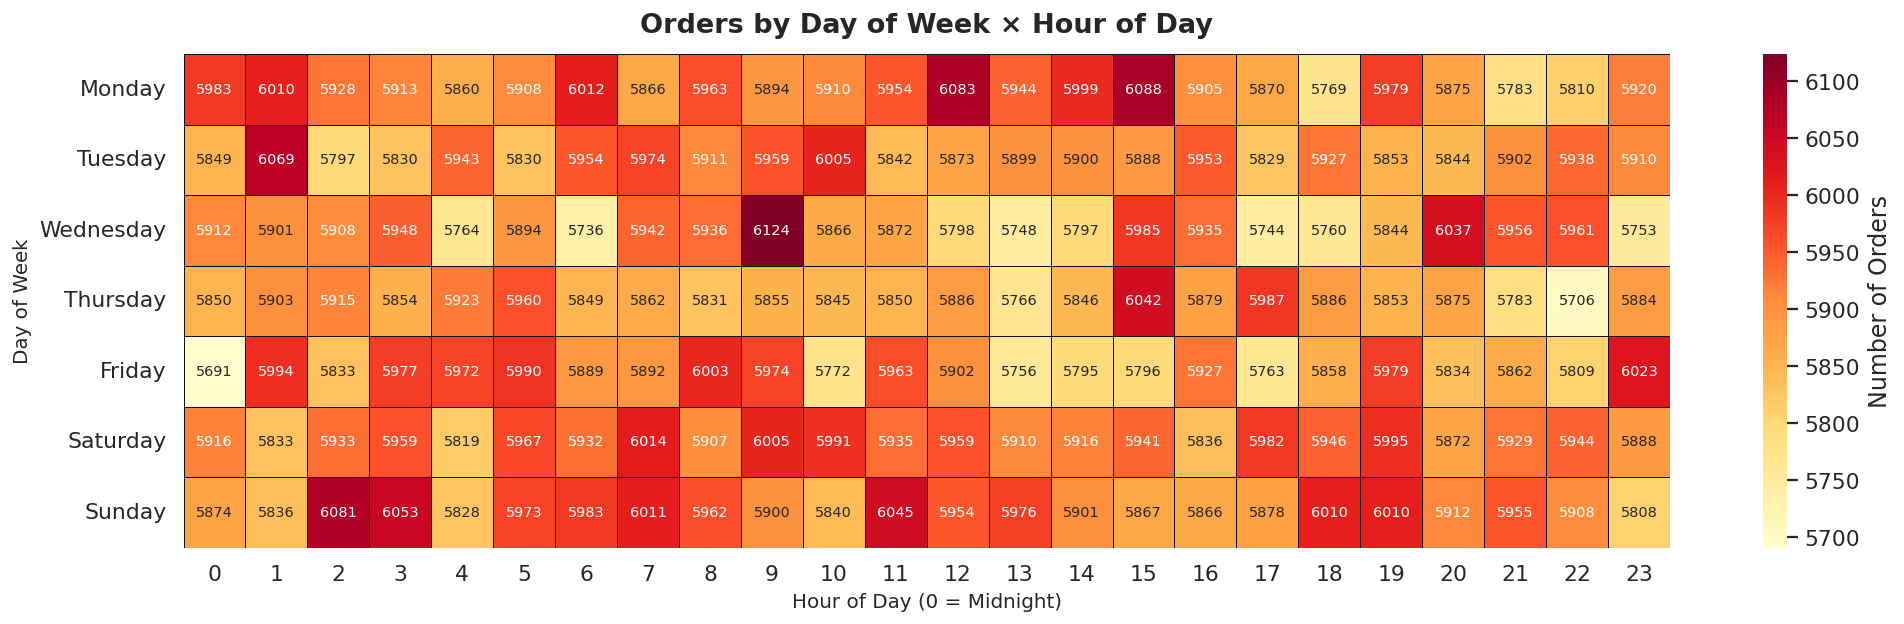

In [191]:

# • Visual 7: Orders by Day of Week × Hour of Day (Heatmap)
# **Why this matters:**
# This heatmap reveals WHEN your customers shop - which day + hour combination sees the most traffic. Marketing teams use this to time push notifications, flash sales, and ad campaigns for maximum impact.

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Calculate the number of orders for each day of week and hour
heatmap_data = df.groupby(["order_day_of_week", "order_hour"])["order_id"] \
               .count() \
               .reset_index(name='Number of Orders') \
               .pivot(index="order_day_of_week", columns="order_hour", values="Number of Orders") \
               .reindex(day_order) # Ensure days are in order

fig1, ax7 = plt.subplots(figsize=(16, 5))
sns.heatmap(
    heatmap_data, ax=ax7,
    cmap="YlOrRd", # A common yellow-orange-red colormap
    linewidths=0.3, linecolor="#0d1117",
    cbar_kws={"label": "Number of Orders"}, fmt=".0f", # Format as integers
    annot=True, # Show the number of orders on the heatmap
    annot_kws={"size": 8} # Adjust annotation font size for readability
)
ax7.set_title("Orders by Day of Week × Hour of Day", fontsize=15, fontweight="bold", pad=12)
ax7.set_xlabel("Hour of Day (0 = Midnight)", fontsize=11)
ax7.set_ylabel("Day of Week", fontsize=11)
plt.tight_layout()
plt.show()

**CELL 17 - VISUAL 8: Profit Margin Distribution**

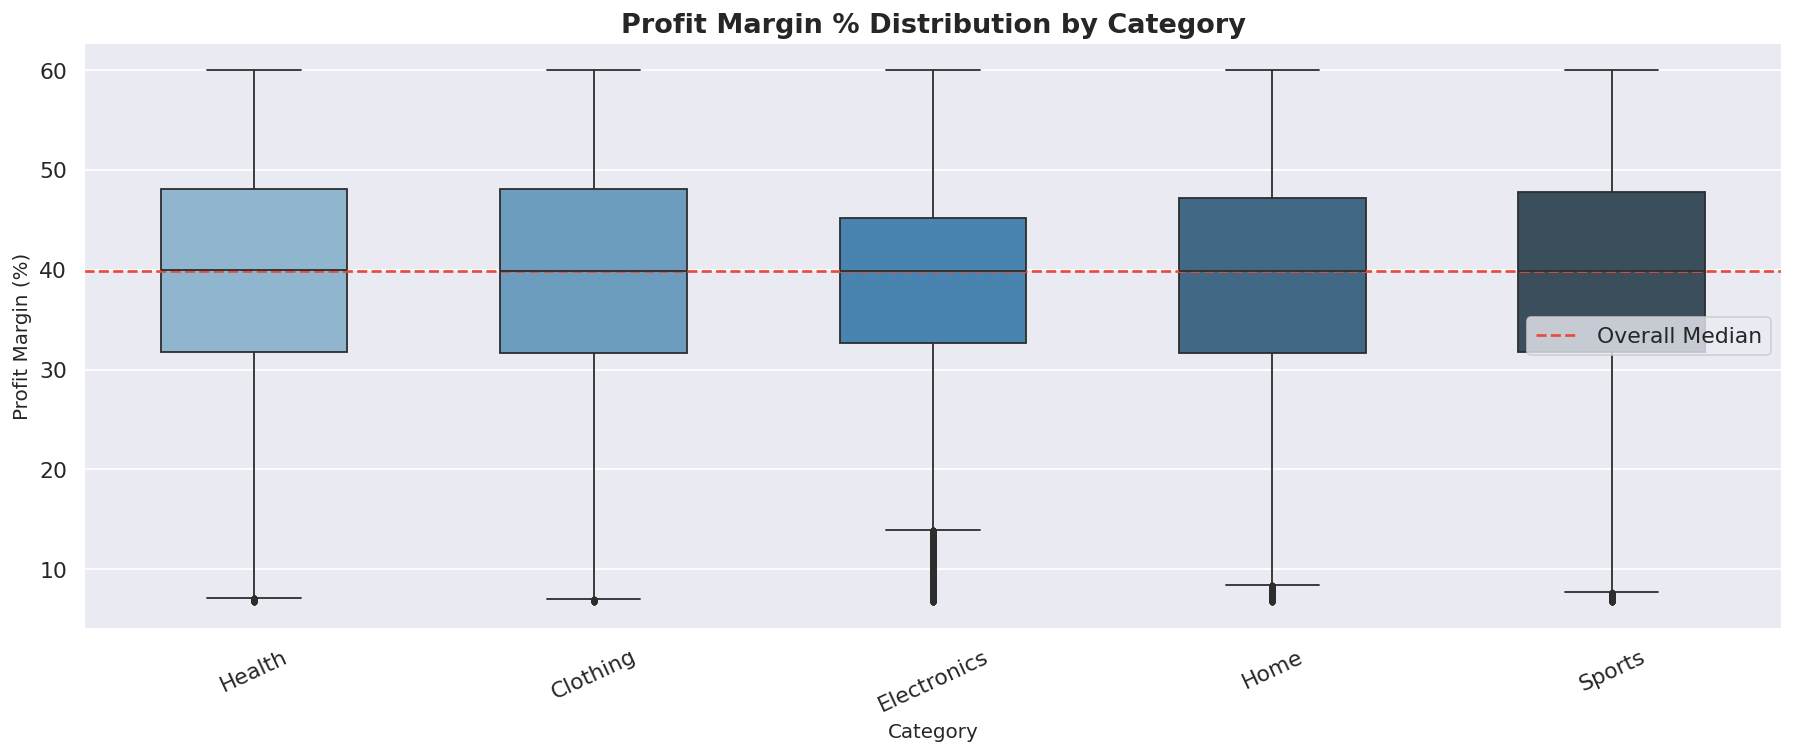

In [192]:

# Visual 8: Profit Margin Distribution by Category (Box Plot)
# **Why this matters:**
# A box plot shows not just averages but the full spread - the best-case, worst-case, and typical-case margins. A category with high median margin but high variance (wide box) is riskier than one with a consistent margin.
# This is a favourite chart of finance teams.
# Variables
fig8, ax8 = plt.subplots(figsize=(14, 6))
order_cats = (
    df.groupby("category")["profit_margin_pct"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)
sns.boxplot(
    data=df,
    x="category", y="profit_margin_pct", order=order_cats,
    palette="Blues_d", width=0.55, fliersize=2, ax=ax8
)
ax8.set_title('Profit Margin % Distribution by Category', fontsize=15, fontweight="bold")
ax8.set_xlabel("Category", fontsize=11)
ax8.set_ylabel("Profit Margin (%)", fontsize=11)
ax8.axhline(df["profit_margin_pct"].median(), color="#E74C3C",
            linestyle="--", linewidth=1.5, label="Overall Median")
ax8.legend()
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

**CELL 18 - VISUAL 9: Top 10 Brands by Revenue**

In [193]:
# Visual 9: Top 10 Brands by Revenue (Treemap)
# **Why this matters:**
# A treemap shows both ranking AND proportional size simultaneously.
# Brand managers and procurement teams use it to see which brands deserve more shelf space, co-marketing investment, or contract renegotiation.

brand_rev = (
    df.groupby("brand")["revenue_after_discount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
fig9 = px.treemap(
    brand_rev, path=["brand"],
    values="revenue_after_discount",
    title="Top 10 Brands by Revenue (Treemap)",
    color="revenue_after_discount",
    color_continuous_scale="Blues"
)
fig9.update_layout(
    paper_bgcolor="#0d1117",
    font_color="#e6edf3",
    title_font_size=18,
    coloraxis_showscale=False
)
fig9.update_traces(textinfo="label+value")
fig9.show()

**CELL 19 - VISUAL 18: Eustomer Loyalty vs. CLV Scatter**

In [194]:

# • Visual 10: Customer Loyalty Score vs.
# Lifetime Value
# **Why this matters:**
# This scatter plot tests the assumption that loyal customers spend more.
# If the correlation is strong, investing in a loyalty programme makes financial sense. If not, there is a strategic misalignment to fix.
# We sample 5,000 rows to keep the chart readable.
sample = df.sample(n=min(5000, len(df)), random_state=42)
fig10 = px.scatter(
sample, x="customer_loyalty_score", y="customer_lifetime_value", color="customer_segment", title="Customer Loyalty Score vs. Lifetime Value",
labels={
"customer_loyalty_score":
"Loyalty Score",
"customer_lifetime_value":
"Lifetime Value (USD)",
"customer_segment":
"Segment"
},
opacity=0.6, color_discrete_sequence=px.colors.qualitative.Bold, trendline="ols"
)
fig10.update_layout(
plot_bgcolor="#0d1117",
paper_bgcolor="#0d1117", font_color="#e6edf3",
title_font_size=18, legend=dict (bgcolor="#161622")
)
fig10.show()

**CELL 20 - PLOTLY DASHBOARD (4-in-1)**

In [195]:
# Step 10: In-Notebook Executive Dashboard
# **Why this matters (the WOW factor):**
# A multi-panel Plotly dashboard is the centrepiece of your project.
# It lets you show four charts in a single, visually cohesive layout - exactly what analysts build for weekly business review meetings.
# This is the one screenshot that will make recruiters stop scrolling.
# **Panel Layout:**
# Monthly Revenue (Line Chart)
# Revenue by Category (Bar Chart)
# Order Status (Funnel Chart)
# Payment Methods (Pie Chart)

#--- Prepare data for dashboard
dash_monthly = (
    df.groupby("order_year_month")["revenue_after_discount"]
    .sum()
    .reset_index()
    .sort_values("order_year_month")
)
dash_cat = (
    df.groupby("category")["revenue_after_discount"]
    .sum()
    .sort_values(ascending=True)
    .reset_index()
)
dash_status = df["order_status"].value_counts().reset_index()
dash_status.columns = ["Status", "Count"]
dash_pay = df["payment_method"].value_counts().reset_index()
dash_pay.columns = ["Method", "Count"]

# --- Build 2x2 subplot dashboard ---
dash = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Monthly Revenue Trend",
        "Revenue by Category",
        "Order Status Distribution",
        "Payment Methods"
    ),
    specs=[
        [{"type": "scatter"}, {"type": "bar"}],
        [{"type": "bar"}, {"type": "pie"}]
    ],
    vertical_spacing=0.18, horizontal_spacing=0.1
)

# Panel 1 - Monthly trend
dash.add_trace(go.Scatter(
    x=dash_monthly["order_year_month"],
    y=dash_monthly["revenue_after_discount"],
    mode="lines+markers", name="Revenue", line=dict(color="#00B4D8", width=2),
    marker=dict(size=5)),
    row=1, col=1
)

# Panel 2 - Category bar
dash.add_trace(
    go.Bar(
        x=dash_cat["revenue_after_discount"],
        y=dash_cat["category"],
        orientation="h",
        marker_color="#48CAE4", name="Category Revenue"
    ),
    row=1, col=2
)

# Panel 3 - Order status
status_colors = ["#2ECC71", "#E74C3C", "#E67E22", "#3498DB", "#9B59B6"]
dash.add_trace(
    go.Bar(
        x=dash_status["Status"],
        y=dash_status["Count"],
        marker_color=status_colors[:len(dash_status)], name="Order Status"
    ),
    row=2, col=1
)

# Panel 4 - Payment pie
dash.add_trace(
    go.Pie(
        labels=dash_pay["Method"],
        values=dash_pay["Count"],
        hole=0.4,
        marker_colors=px.colors.sequential.Blues_r[:len(dash_pay)],
        name="Payments"
    ),
    row=2, col=2
)

dash.update_layout(
    title=dict(
        text="GLOBAL E-COMMERCE EXECUTIVE DASHBOARD (2024-2026)",
        font=dict(size=20, color="#e6edf3"),
        x=0.5, xanchor="center"
    ),
    plot_bgcolor="#0d1117",
    paper_bgcolor="#0d1117",
    font_color="#e6edf3",
    height=800,
    showlegend=False,
    margin=dict(t=100, b=40, l=40, r=40)
)

# Style all axes to match dark theme
for axis in ["xaxis", "yaxis", "xaxis2", "yaxis2", "xaxis3", "yaxis3"]:
    dash.update_layout(**{
        axis: dict(
            gridcolor="#21262d", linecolor="#30363d", tickfont=dict(color="#8b949e")
        )
    })
dash.show()
print("Dashboard rendered! Screenshot this view for your resume/portfolio.")

Dashboard rendered! Screenshot this view for your resume/portfolio.


**CELL 21 - FINAL INSIGHTS SUMMARY**

In [196]:
#Step 11: Final Business Insights & Recommendations
# **Why this matters:**
# Data without interpretation is just noise. A senior analyst always closes with actionable recommendations.
# This is the section that demonstrates
# your business thinking - not just your coding skills.

print("=" * 65)
print("FINAL BUSINESS INSIGHTS & RECOMMENDATIONS")
print("=" * 65)

top10_countries = (
    df.groupby("country")["revenue_after_discount"]
    .sum().sort_values(ascending=False).head(3).index.tolist()
)
top3_cats = (
    df.groupby("category")["profit_margin_pct"]
    .median().sort_values(ascending=False).head(3).index.tolist()
)
# Removed duplicate definition of top3_cats
worst_margin_cat = (
    df.groupby("category")["profit_margin_pct"]
    .median().idxmin()
)
peak_hour = df["order_hour"].value_counts().idxmax()
top_payment = df["payment_method"].value_counts().idxmax()
return_rate = (df["order_status"] == "Returned").mean() * 100
cancel_rate = (df["order_status"] == "Cancelled").mean() * 100

print(f"""
INSIGHT 1 - GEOGRAPHIC FOCUS
Top 3 revenue markets: {', '.join(top10_countries)}
RECOMMENDATION: Increase ad spend and localized promotions
in these markets; consider local warehousing to cut delivery days.
""")

print(f"""
INSIGHT 2 - CATEGORY STRATEGY
Highest margin categories: {', '.join(top3_cats)}
Lowest margin category: {worst_margin_cat}
RECOMMENDATION: Upsell high-margin categories with bundling and cross-sell campaigns.
Review supplier contracts for
'{worst_margin_cat}' to improve cost structure.
""")

print(f"""
INSIGHT 3 - TIMING & CAMPAIGN PLANNING
Peak shopping hour: {peak_hour}:00
RECOMMENDATION: Schedule push notifications, flash sales,
and email campaigns to launch at {peak_hour}:00 for maximum CTR.
""")

print(f"""
INSIGHT 4 - PAYMENT OPTIMISATION
Dominant payment method: {top_payment}
RECOMMENDATION: Ensure this gateway has 99.9% uptime.
Offer exclusive discounts for underused payment methods
to diversify dependency.
""")

print(f"""
INSIGHT 5 - RETURNS & CANCELLATIONS (RISK ALERT)
Return rate: {return_rate:.1f}%
Cancel rate: {cancel_rate:.1f}%
RECOMMENDATION: Investigate return reasons per category.

If > 10% returns in any category, trigger a product quality review.
Cancellations > 15% may signal checkout UX issues.
""")
print("=" *
65)
print ("End-to-End Analysis Complete! Save this notebook to GitHub")
print("and add it to your Resume / LinkedIn portfolio.")
print ("=" * 65)

FINAL BUSINESS INSIGHTS & RECOMMENDATIONS

INSIGHT 1 - GEOGRAPHIC FOCUS
Top 3 revenue markets: Netherlands, Belgium, Italy
RECOMMENDATION: Increase ad spend and localized promotions
in these markets; consider local warehousing to cut delivery days.


INSIGHT 2 - CATEGORY STRATEGY
Highest margin categories: Health, Clothing, Electronics
Lowest margin category: Electronics
RECOMMENDATION: Upsell high-margin categories with bundling and cross-sell campaigns.
Review supplier contracts for
'Electronics' to improve cost structure.


INSIGHT 3 - TIMING & CAMPAIGN PLANNING
Peak shopping hour: 9:00
RECOMMENDATION: Schedule push notifications, flash sales,
and email campaigns to launch at 9:00 for maximum CTR.


INSIGHT 4 - PAYMENT OPTIMISATION
Dominant payment method: Debit Card
RECOMMENDATION: Ensure this gateway has 99.9% uptime.
Offer exclusive discounts for underused payment methods
to diversify dependency.


INSIGHT 5 - RETURNS & CANCELLATIONS (RISK ALERT)
Return rate: 10.0%
Cancel rate: 5